# Concatenation Experiment
## generate data manifolds $X_1$, $X_2$, of dimension N * d1, N * d2, 
## each one either uniform, Pareto or Cauchy
## calculate nu/d for each
## concatenate, to give $X_{12} := X_1 \oplus X_2$ of dimension N * (d1 + d2)
## calculate nu/d, and implied alpha, for X12


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

# Experiment One : Pareto

In [31]:
N = 2000
d1 = 500
d2 = 500
num_iterations = 100
nu_over_d_X1_vals = np.zeros(num_iterations)
nu_over_d_X2_vals = np.zeros(num_iterations)
nu_over_d_X1concatX2_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
upper_bound_2_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

alpha_X1 = 0.0
alpha_X2 = 0.0
pareto_uniform_draws = True
force_pareto = True
force_uniform = False
force_cauchy = False
verbose = False

for i in range(num_iterations):
    alpha_X1 = np.random.uniform(0.1,5.0)
    alpha_X2 = np.random.uniform(0.1,5.0)
    results_dict = pp.concatenation_experiment(N,d1,d2,alpha_X1, alpha_X2, pareto_uniform_draws, force_pareto, force_uniform, force_cauchy, verbose)
    nu_over_d_X1 = results_dict["nu_over_d_X1"]
    nu_over_d_X2 = results_dict["nu_over_d_X2"]
    nu_over_d_X1concatX2 = results_dict["nu_over_d_X1concatX2"]
    upper_bound = min(nu_over_d_X1, nu_over_d_X2)
    upper_bound_2 = max(nu_over_d_X1, nu_over_d_X2)
    lower_bound = nu_over_d_X1 * nu_over_d_X2
    print(i, nu_over_d_X1, nu_over_d_X2, nu_over_d_X1concatX2, lower_bound, upper_bound)

    nu_over_d_X1_vals[i] = nu_over_d_X1
    nu_over_d_X2_vals[i] = nu_over_d_X2
    nu_over_d_X1concatX2_vals[i] = nu_over_d_X1concatX2
    upper_bound_vals[i] = upper_bound
    upper_bound_2_vals[i] = upper_bound_2
    lower_bound_vals[i] = lower_bound

this_random =  1 False True False
False True False
this_random =  1 False True False
False True False
0 0.8848692665659997 0.21134373919243632 0.1920057610258447 0.18701157949252706 0.21134373919243632
this_random =  0 True False False
True False False
this_random =  0 True False False
True False False
1 0.7998583477245217 0.522620110791533 0.5467421982238043 0.4180220583053221 0.522620110791533
this_random =  1 False True False
False True False
this_random =  2 False False True
False False True
2 0.8411763166461457 0.002420498672466712 0.0012102494535472684 0.0020360661577524344 0.002420498672466712
this_random =  2 False False True
False False True
this_random =  2 False False True
False False True
3 0.883271254253735 0.8659319550943673 0.813854367811961 0.7648528040745907 0.8659319550943673
this_random =  1 False True False
False True False
this_random =  0 True False False
True False False
4 0.7378852400978956 0.6733845425013757 0.6558025192532764 0.49688051482183915 0.673384542501

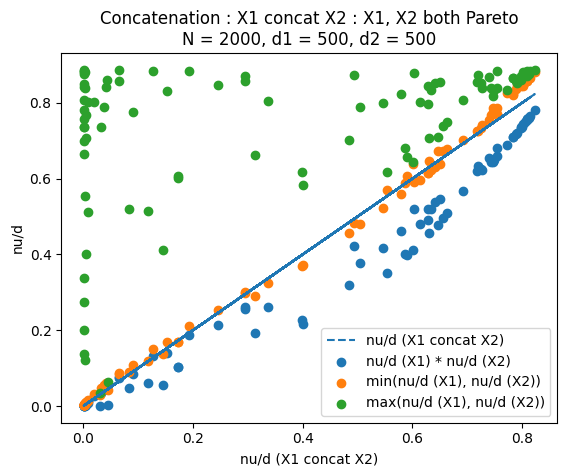

In [35]:
this_title = "Concatenation : X1 concat X2 : X1, X2 both Pareto\n"
this_title += "N = " + str(N) + ", d1 = " + str(d1) + ", d2 = " + str(d2)

plt.plot(nu_over_d_X1concatX2_vals, nu_over_d_X1concatX2_vals, linestyle = "--", label="nu/d (X1 concat X2)")
plt.scatter(nu_over_d_X1concatX2_vals, lower_bound_vals, label = "nu/d (X1) * nu/d (X2)") #, color='red')
plt.scatter(nu_over_d_X1concatX2_vals, upper_bound_vals, label = "min(nu/d (X1), nu/d (X2))") #, color='blue')
plt.scatter(nu_over_d_X1concatX2_vals, upper_bound_2_vals, label = "max(nu/d (X1), nu/d (X2))")# , color='green')
plt.xlabel("nu/d (X1 concat X2)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('X1_concat_X2_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Experiment Two : Cauchy

In [41]:
N = 2000
d1 = 500
d2 = 500
num_iterations = 100
nu_over_d_X1_vals = np.zeros(num_iterations)
nu_over_d_X2_vals = np.zeros(num_iterations)
nu_over_d_X1concatX2_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
upper_bound_2_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

alpha_X1 = 0.0
alpha_X2 = 0.0
pareto_uniform_draws = False
force_pareto = False
force_uniform = False
force_cauchy = True
verbose = False

for i in range(num_iterations):
    alpha_X1 = np.random.uniform(0.1,5.0)
    alpha_X2 = np.random.uniform(0.1,5.0)
    results_dict = pp.concatenation_experiment(N,d1,d2,alpha_X1, alpha_X2, pareto_uniform_draws, force_pareto, force_uniform, force_cauchy, verbose)
    nu_over_d_X1 = results_dict["nu_over_d_X1"]
    nu_over_d_X2 = results_dict["nu_over_d_X2"]
    nu_over_d_X1concatX2 = results_dict["nu_over_d_X1concatX2"]
    upper_bound = min(nu_over_d_X1, nu_over_d_X2)
    upper_bound_2 = max(nu_over_d_X1, nu_over_d_X2)
    lower_bound = nu_over_d_X1 * nu_over_d_X2
    print(i, nu_over_d_X1, nu_over_d_X2, nu_over_d_X1concatX2, lower_bound, upper_bound, upper_bound_2)

    nu_over_d_X1_vals[i] = nu_over_d_X1
    nu_over_d_X2_vals[i] = nu_over_d_X2
    nu_over_d_X1concatX2_vals[i] = nu_over_d_X1concatX2
    upper_bound_vals[i] = upper_bound
    upper_bound_2_vals[i] = upper_bound_2
    lower_bound_vals[i] = lower_bound

this_random =  0 True False False
True False False
this_random =  2 False False True
False False True
0 0.04964345646816502 0.06008928423779686 0.053405283734038606 0.002983039766262263 0.04964345646816502 0.06008928423779686
this_random =  1 False True False
False True False
this_random =  2 False False True
False False True
1 0.16849631663665915 0.05932372108542222 0.07025910406879667 0.009995828492074156 0.05932372108542222 0.16849631663665915
this_random =  2 False False True
False False True
this_random =  0 True False False
True False False
2 0.08330236431990064 0.020726157357108137 0.01750729795176333 0.0017265379111134108 0.020726157357108137 0.08330236431990064
this_random =  2 False False True
False False True
this_random =  1 False True False
False True False
3 0.03793091160718267 0.02813989614692947 0.03241521674831879 0.0010673719133844819 0.02813989614692947 0.03793091160718267
this_random =  2 False False True
False False True
this_random =  2 False False True
False Fals

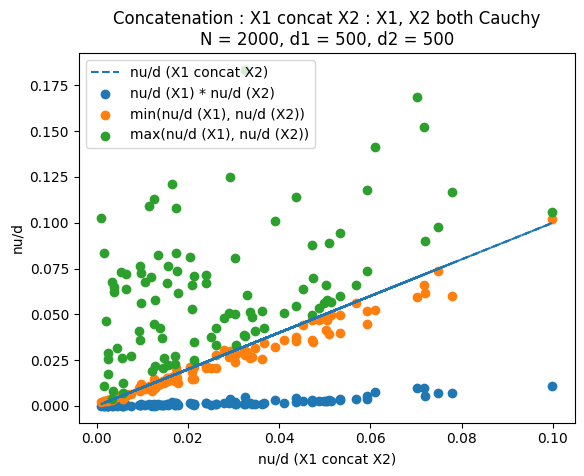

In [43]:
this_title = "Concatenation : X1 concat X2 : X1, X2 both Cauchy\n"
this_title += "N = " + str(N) + ", d1 = " + str(d1) + ", d2 = " + str(d2)

plt.plot(nu_over_d_X1concatX2_vals, nu_over_d_X1concatX2_vals, linestyle = "--", label="nu/d (X1 concat X2)")
plt.scatter(nu_over_d_X1concatX2_vals, lower_bound_vals, label = "nu/d (X1) * nu/d (X2)")
plt.scatter(nu_over_d_X1concatX2_vals, upper_bound_vals, label = "min(nu/d (X1), nu/d (X2))")
plt.scatter(nu_over_d_X1concatX2_vals, upper_bound_2_vals, label = "max(nu/d (X1), nu/d (X2))")
plt.xlabel("nu/d (X1 concat X2)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('X1_concat_X2_cauchy.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Experiment Three : uniform

In [38]:
N = 2000
d1 = 500
d2 = 500
num_iterations = 20
nu_over_d_X1_vals = np.zeros(num_iterations)
nu_over_d_X2_vals = np.zeros(num_iterations)
nu_over_d_X1concatX2_vals = np.zeros(num_iterations)
upper_bound_vals = np.zeros(num_iterations)
upper_bound_2_vals = np.zeros(num_iterations)
lower_bound_vals = np.zeros(num_iterations)

alpha_X1 = 0.0
alpha_X2 = 0.0
pareto_uniform_draws = False
force_pareto = False
force_uniform = True
force_cauchy = False
verbose = False

for i in range(num_iterations):
    alpha_X1 = np.random.uniform(0.1,5.0)
    alpha_X2 = np.random.uniform(0.1,5.0)
    results_dict = pp.concatenation_experiment(N,d1,d2,alpha_X1, alpha_X2, pareto_uniform_draws, force_pareto, force_uniform, force_cauchy, verbose)
    nu_over_d_X1 = results_dict["nu_over_d_X1"]
    nu_over_d_X2 = results_dict["nu_over_d_X2"]
    nu_over_d_X1concatX2 = results_dict["nu_over_d_X1concatX2"]
    upper_bound = min(nu_over_d_X1, nu_over_d_X2)
    upper_bound_2 = max(nu_over_d_X1, nu_over_d_X2)
    lower_bound = nu_over_d_X1 * nu_over_d_X2
    print(i, nu_over_d_X1, nu_over_d_X2, nu_over_d_X1concatX2, lower_bound, upper_bound, upper_bound_2)

    nu_over_d_X1_vals[i] = nu_over_d_X1
    nu_over_d_X2_vals[i] = nu_over_d_X2
    nu_over_d_X1concatX2_vals[i] = nu_over_d_X1concatX2
    upper_bound_vals[i] = upper_bound
    upper_bound_2_vals[i] = upper_bound_2
    lower_bound_vals[i] = lower_bound

this_random =  2 False False True
False False True
this_random =  1 False True False
False True False
0 0.7211605103934485 0.7006245909642719 0.6703191517954318 0.5052627876139955 0.7006245909642719 0.7211605103934485
this_random =  0 True False False
True False False
this_random =  2 False False True
False False True
1 0.7043856340702636 0.7058399503396914 0.6648873664180741 0.49718352097214685 0.7043856340702636 0.7058399503396914
this_random =  2 False False True
False False True
this_random =  0 True False False
True False False
2 0.697170809354545 0.7119127587747989 0.6647644864759485 0.4963247942248535 0.697170809354545 0.7119127587747989
this_random =  1 False True False
False True False
this_random =  1 False True False
False True False
3 0.7142345001448344 0.705676260428436 0.6695926237388011 0.50401833113118 0.705676260428436 0.7142345001448344
this_random =  2 False False True
False False True
this_random =  1 False True False
False True False
4 0.716294597697346 0.696389146

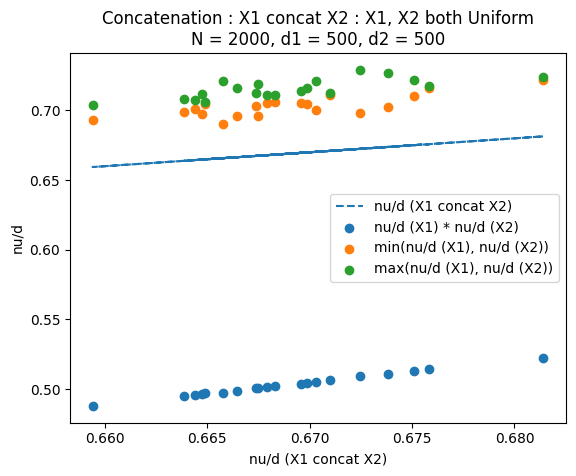

In [40]:
this_title = "Concatenation : X1 concat X2 : X1, X2 both Uniform\n"
this_title += "N = " + str(N) + ", d1 = " + str(d1) + ", d2 = " + str(d2)

plt.plot(nu_over_d_X1concatX2_vals, nu_over_d_X1concatX2_vals, linestyle = "--", label="nu/d (X1 concat X2)")
plt.scatter(nu_over_d_X1concatX2_vals, lower_bound_vals, label = "nu/d (X1) * nu/d (X2)")
plt.scatter(nu_over_d_X1concatX2_vals, upper_bound_vals, label = "min(nu/d (X1), nu/d (X2))")
plt.scatter(nu_over_d_X1concatX2_vals, upper_bound_2_vals, label = "max(nu/d (X1), nu/d (X2))")
plt.xlabel("nu/d (X1 concat X2)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('X1_concat_X2_uniform.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
for i in range(0,10):
    this_random = np.random.randint(0, 3)
    #this_random = int(np.random.uniform(0,3))
    print("this_random = ", this_random)
    use_pareto = this_random == 0
    use_uniform = this_random == 1
    use_cauchy = this_random == 2
    print(use_pareto, use_uniform, use_cauchy)